## Avaliação 1 - AEDS 2
Alunos:
- Rafael Eustáquio Pinto    
- Daniel Cristo
- Arthur de Brito Silva



In [1]:
"""
    Implementação dos métodos de inserção e busca em uma Árvore AVL
"""

import sys
sys.setrecursionlimit(200000) # Define um limite seguro acima de 100.000

class AVLNode:
    def __init__(self, key):
        """método construtor dos nós"""
        if not isinstance(key, int):  # rejeita qualquer valor não inteiro
            raise TypeError("A chave deve ser um número inteiro")
        self.key = key  # número do nó
        self.left = None  # nó 'filho' da esquerda
        self.right = None  # nó 'filho' da direita
        self.height = 1  # altura do nó na árvore


# ---------------------------------------------------------------------------

class AVLTree:
    def __init__(self):
        """cria a árvore vazia"""
        self.root = None  # raiz da árvore

    def _height(self, node):
        """retorna a altura do nó"""
        if not node:  # se o nó não existir
            return 0
        return node.height

    def _balance_factor(self, node):
        """calcula o fator de balanceamento"""
        if not node:
            return 0
        return self._height(node.left) - self._height(node.right)

    def _rotate_right(self, y):
        """rotação simples para a direita"""
        x = y.left
        T2 = x.right

        x.right = y
        y.left = T2

        # atualiza as alturas após a rotação
        y.height = 1 + max(self._height(y.left), self._height(y.right))
        x.height = 1 + max(self._height(x.left), self._height(x.right))

        return x

    def _rotate_left(self, x):
        """rotação simples para a esquerda"""
        y = x.right
        T2 = y.left

        y.left = x
        x.right = T2

        # atualiza as alturas após a rotação
        x.height = 1 + max(self._height(x.left), self._height(x.right))
        y.height = 1 + max(self._height(y.left), self._height(y.right))

        return y

    def insert(self, key):
        """método público para inserção"""
        self.root = self._insert(self.root, key)

    def _insert(self, root, key):
        """insere um novo nó na árvore"""
        if not root:  # se chegar em uma posição vazia
            return AVLNode(key)

        if key < root.key:
            root.left = self._insert(root.left, key)
        elif key > root.key:
            root.right = self._insert(root.right, key)
        else:
            return root # garante que não haverá duplicatas

        root.height = 1 + max(self._height(root.left), self._height(root.right))

        balance = self._balance_factor(root)

        # rotação direita
        if balance > 1:
            if key < root.left.key:
                return self._rotate_right(root)
            else:
                root.left = self._rotate_left(root.left)
                return self._rotate_right(root)

        # rotação esquerda
        if balance < -1:
            if key > root.right.key:
                return self._rotate_left(root)
            else:
                root.right = self._rotate_right(root.right)
                return self._rotate_left(root)

        return root

    def get(self, key):
        """método de busca"""
        if not isinstance(key, int):
            raise TypeError("A chave de busca deve ser um número inteiro")

        node = self.root
        comparisons = 0 
        
        while node:
            comparisons += 1
            if key == node.key:
                return node.key, comparisons
            elif key < node.key:
                node = node.left
            else:
                node = node.right

        return None, comparisons

In [2]:
"""
    Implementação dos métodos de inserção e busca em uma Aŕvore Binária de Pesquisa Sem Balanceamento
"""


class BSTNode:
    def __init__(self, valor):
        if not isinstance(valor, int):
            raise TypeError("A chave deve ser um número inteiro")
        self.esquerda = None
        self.direita = None
        self.valor = valor


class BSTree:
    def __init__(self):
        self.root = None

    def insert(self, valor):
        if self.root is None:
            self.root = BSTNode(valor)
            return

        temp = self.root

        while True:
            if valor < temp.valor:
                if temp.esquerda is None:
                    temp.esquerda = BSTNode(valor)
                    return
                else:
                    temp = temp.esquerda
            elif valor > temp.valor:
                if temp.direita is None:
                    temp.direita = BSTNode(valor)
                    return
                else:
                    temp = temp.direita
            else:
                return # valor existente, só sai do metodo

    def get(self, valor):
        if not isinstance(valor, int):
            raise TypeError("A chave de busca deve ser um número inteiro")
        
        temp = self.root
        comp = 0
        while temp is not None:
            comp += 1
            if valor < temp.valor:
                temp = temp.esquerda
            elif valor > temp.valor:
                temp = temp.direita
            else:
                return (temp.valor, comp)
            
        return None, comp

Executando experimentos na Árvore BST...
	Tabela da Árvore Binária 
        N  Comparações (Ordenado)  Comparações (Aleatório)
0   10000                   10000                        7
1   20000                   20000                        8
2   30000                   30000                       12
3   40000                   40000                       13
4   50000                   50000                        9
5   60000                   60000                        9
6   70000                   70000                        7
7   80000                   80000                       10
8   90000                   90000                        9
9  100000                  100000                       12


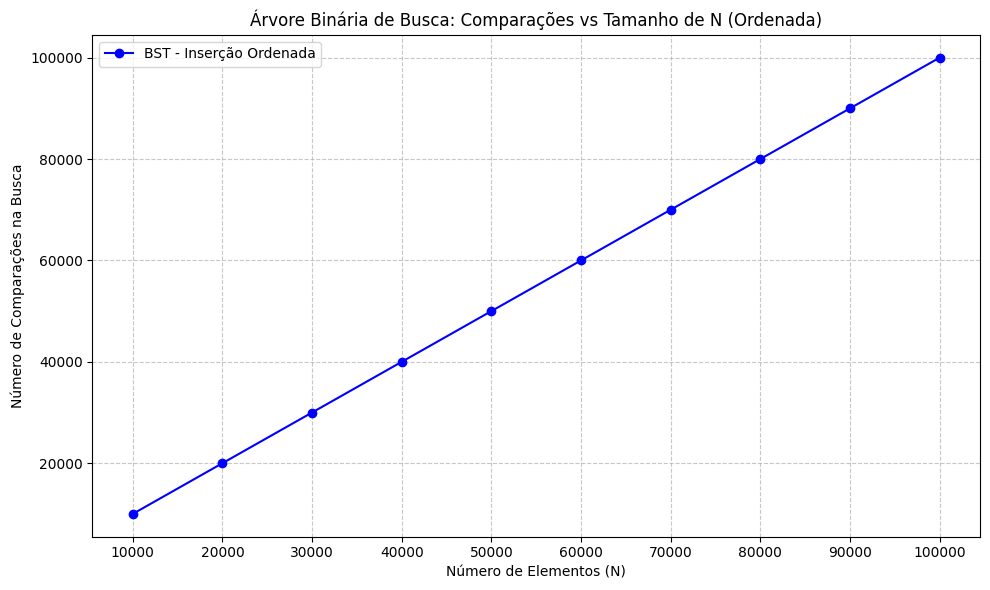

In [4]:
""" Experimentos na Árvore Binária de Pesquisa sem Balanceamento BST"""

import random
import pandas as pd
import matplotlib.pyplot as plt

print("Executando experimentos na Árvore BST...")

#Parte Ordenada
comp_ordenada = []

for j in range(10_000, 100_001, 10_000):
    raiz = BSTree()
    for n in range (1, j + 1):
        raiz.insert(n)
    _, comp = raiz.get(100_001)
    comp_ordenada.append(comp)
   

#Parte Desordenada
comp_aleatoria = []

for i in range(10_000, 100_001, 10_000):
    lista = list(range(1, i + 1))      #coloca do 1 até a última dezena de milhar desejada
    random.shuffle(lista)

    raiz = BSTree()              #começa a árvore com o primeiro número

    for n in lista:
        raiz.insert(n)          #insere os demais números na ordem aleatória
    
    _, comp = raiz.get(100_001)
    comp_aleatoria.append(comp)                #ao final, busca o 100_001

values = list(range(10_000, 100_001, 10_000))

dados ={'N': values,
        'Comparações (Ordenado)': comp_ordenada,
        'Comparações (Aleatório)': comp_aleatoria}

tabela = pd.DataFrame(dados)
print(f"\tTabela da Árvore Binária \n{tabela}") 


plt.figure(figsize=(10, 6))
plt.plot(values, comp_ordenada, marker='o', linestyle='-', color='b', label='BST - Inserção Ordenada')

plt.title('Árvore Binária de Busca: Comparações vs Tamanho de N (Ordenada)')
plt.xlabel('Número de Elementos (N)')
plt.ylabel('Número de Comparações na Busca')

plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.xticks(values)
plt.tight_layout()

plt.savefig('grafico_bst_comparacoes.png')
plt.show()




Executando experimentos na Árvore AVL...


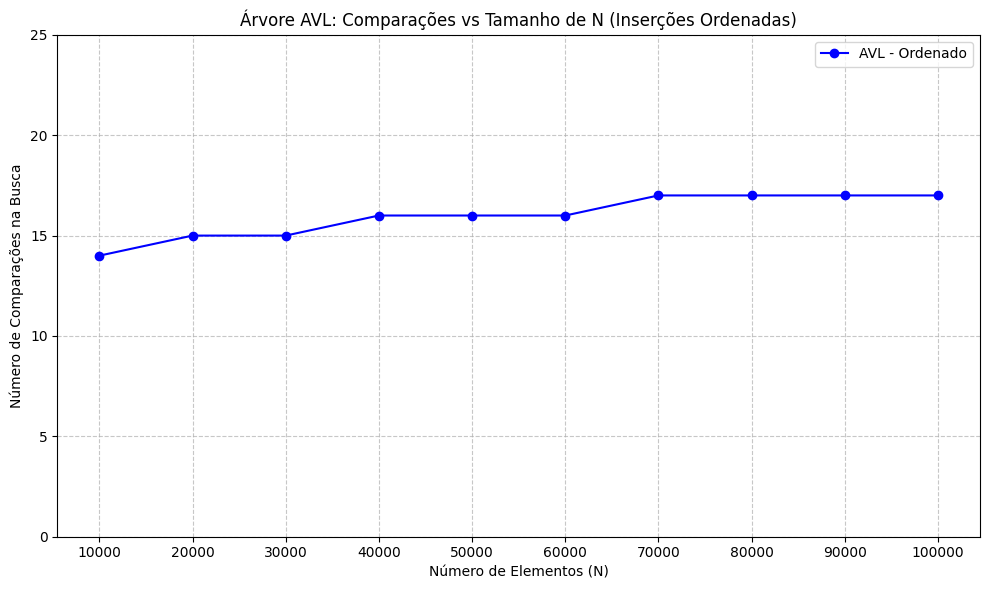


Tabela de Resultados - Árvore AVL:
     N  Comparações (Ordenado)  Comparações (Aleatório)
 10000                      14                       13
 20000                      15                       16
 30000                      15                       14
 40000                      16                       15
 50000                      16                       16
 60000                      16                       14
 70000                      17                       16
 80000                      17                       17
 90000                      17                       18
100000                      17                       15


In [5]:
"""Experimentos na Árvore AVL"""

import matplotlib.pyplot as plt
import pandas as pd
from random import sample

# inicialização das listas para guardar os resultados
n_values = list(range(10000, 100001, 10000))
comparisons_ordered = []
comparisons_random = []

print("Executando experimentos na Árvore AVL...")

# elementos ordenados
for n in n_values:
    tree = AVLTree()
    for i in range(1, n+1):
        tree.insert(i)
    _, comp = tree.get(100001)
    comparisons_ordered.append(comp)

# elementos aleatorios
for n in n_values:
    tree = AVLTree()
    for i in sample(range(1, n+1), n):
        tree.insert(i)
    _, comp = tree.get(100001)
    comparisons_random.append(comp)
    
# ---------------------------------------------------------------------------
# Geração do Gráfico

plt.figure(figsize=(10, 6))
plt.plot(n_values, comparisons_ordered, marker='o', linestyle='-', color='b', label='AVL - Ordenado')

plt.title('Árvore AVL: Comparações vs Tamanho de N (Inserções Ordenadas)')
plt.xlabel('Número de Elementos (N)')
plt.ylabel('Número de Comparações na Busca')

# O limite superior (ex: 25) acomoda o pior caso teórico para N=100.000
plt.ylim(0, 25) 

plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.xticks(n_values)
plt.tight_layout()

plt.savefig('grafico_avl_ordenado.png')
plt.show()


# Geração da tabela
df_resultados = pd.DataFrame({
    'N': n_values,
    'Comparações (Ordenado)': comparisons_ordered,
    'Comparações (Aleatório)': comparisons_random
})

print("\nTabela de Resultados - Árvore AVL:")
print(df_resultados.to_string(index=False))